In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import sys
import datetime


In [59]:
df = pd.read_csv('data/paragon.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31057 entries, 0 to 31056
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   COMPANY_NAME           31057 non-null  object 
 1   PLANT_NAME             30856 non-null  object 
 2   EQUIPMENT_CODE         30856 non-null  object 
 3   COUNTER_CODE           31057 non-null  object 
 4   SHOT_START_TIME        31057 non-null  int64  
 5   SHOT_END_TIME          31057 non-null  int64  
 6   CYCLE_TIME_LIMIT1      30856 non-null  float64
 7   CYCLE_TIME_LIMIT1UNIT  30856 non-null  object 
 8   CYCLE_TIME_LIMIT2      30856 non-null  float64
 9   CYCLE_TIME_LIMIT2UNIT  30856 non-null  object 
 10  L1_ABOVE_ADJUSTED      30856 non-null  float64
 11  L2_ABOVE_ADJUSTED      30856 non-null  float64
 12  L1_BELOW_ADJUSTED      30856 non-null  float64
 13  L2_BELOW_ADJUSTED      30856 non-null  float64
 14  CONTRACTED_CYCLE_TIME  30856 non-null  float64
 15  AV

In [ ]:
# #connection between snowflake and python

# import snowflake.connector
# import snowflake.connector.pandas_tools as sfpd
# from snowflake.sqlalchemy import URL
# from sqlalchemy import create_engine


# #snowflake connection
# conn = snowflake.connector.connect(   # these are demo for now , i will add the real credentials later
#     user='david',
#     password='David',
#     account='jvz77991.us-east-1',
#     warehouse='COMPUTE_WH', 
#     database='DEMO_DB', 
#     schema='PUBLIC' 
    
# )
# #sqlalchemy engine
# engine = create_engine(URL(
#     user='david',
#     password='David',
#     account='jvz77991.us-east-1',
#     warehouse='COMPUTE_WH', 
#     database='DEMO_DB', 
#     schema='PUBLIC' 
# ))


          EQUIPMENT_CODE AVG_VALID_CT            SHOT_COUNT UPTIME_PERCENTAGE
                                 mean        std        sum              mean
0  221000098-01-N01-1001    14.470878   8.980833      49160         97.473512
1  221000098-02-N01-1001    15.259439  12.910472     128660         98.189140
2  221000098-03-N01-1001    14.891710  10.221210     167278         97.732917
3           500001070/78    24.982275   6.092471      69716         94.010225
4         500001071/79 A    20.994474  16.427939      12996         96.214868


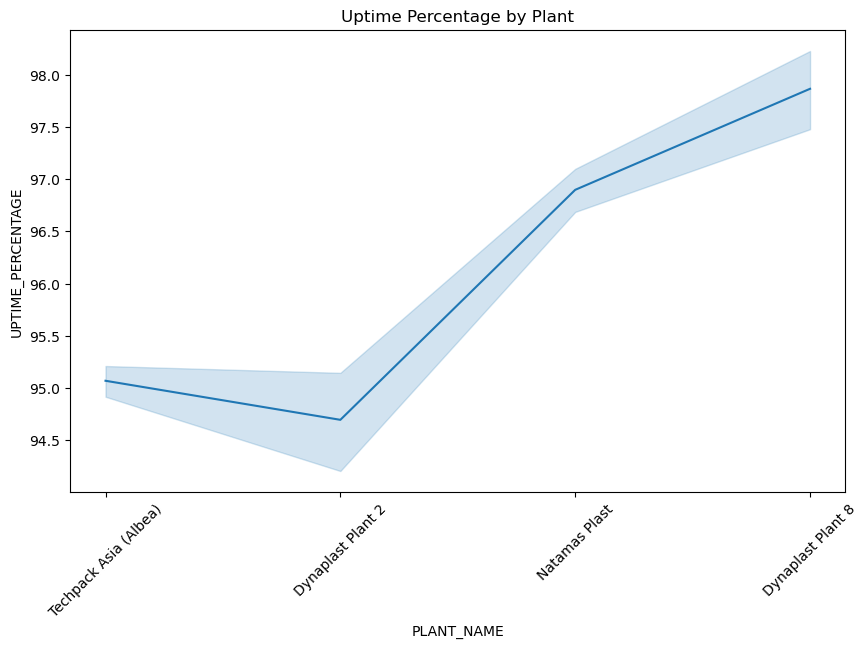

In [60]:
#descriptive analysis

agg_metrics = df.groupby('EQUIPMENT_CODE').agg(
    {'AVG_VALID_CT': ['mean', 'std'],
     'SHOT_COUNT': 'sum', 
     'UPTIME_PERCENTAGE': 'mean'
     }).reset_index()

#print summary 
print(agg_metrics.head())

#uptime trends visualization
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='PLANT_NAME', y='UPTIME_PERCENTAGE')
plt.xticks(rotation=45)
plt.title('Uptime Percentage by Plant')
plt.show()

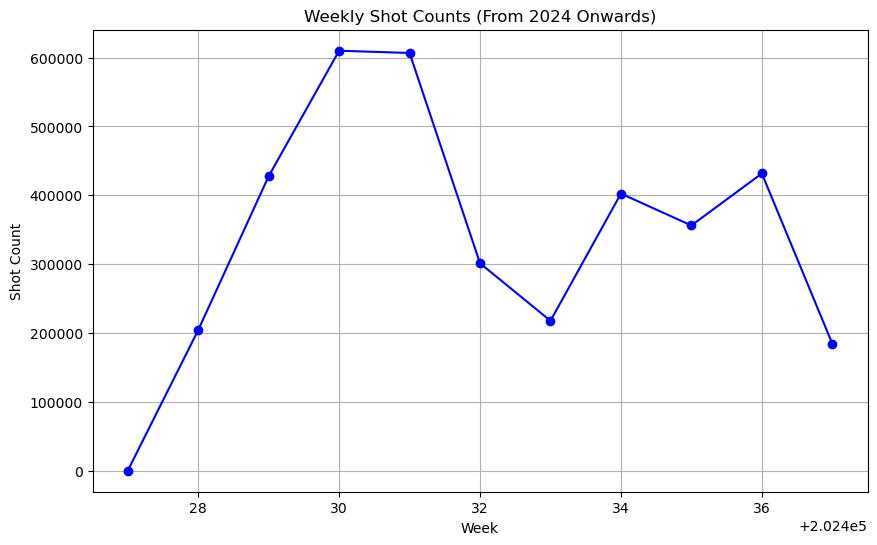

In [61]:
# Convert WEEK to integers
df['WEEK'] = df['WEEK'].astype(int)

# Filter data to include only weeks starting from 2024
weekly_shots = df[df['WEEK'] >= 202401]

# Aggregate weekly shot counts
weekly_shots = weekly_shots.groupby('WEEK')['SHOT_COUNT'].sum().reset_index()
weekly_shots.columns = ['Week', 'TOTAL_SHOTS']

# Plot weekly shot counts
plt.figure(figsize=(10, 6))
plt.plot(weekly_shots['Week'], weekly_shots['TOTAL_SHOTS'], marker='o', color='blue')
plt.title('Weekly Shot Counts (From 2024 Onwards)')
plt.xlabel('Week')
plt.ylabel('Shot Count')
plt.grid()
plt.show()


In [62]:
df_cleaned = df.dropna()


In [63]:
print(df_cleaned.isna().sum())


COMPANY_NAME             0
PLANT_NAME               0
EQUIPMENT_CODE           0
COUNTER_CODE             0
SHOT_START_TIME          0
SHOT_END_TIME            0
CYCLE_TIME_LIMIT1        0
CYCLE_TIME_LIMIT1UNIT    0
CYCLE_TIME_LIMIT2        0
CYCLE_TIME_LIMIT2UNIT    0
L1_ABOVE_ADJUSTED        0
L2_ABOVE_ADJUSTED        0
L1_BELOW_ADJUSTED        0
L2_BELOW_ADJUSTED        0
CONTRACTED_CYCLE_TIME    0
AVG_VALID_CT             0
SHOT_COUNT               0
ABOVE_COUNT              0
WITHIN_COUNT             0
BELOW_COUNT              0
ABOVE_AVG_CT             0
WITHIN_AVG_CT            0
BELOW_AVG_CT             0
SHOTS_MADE               0
VALID_SHOT_COUNT         0
PRODUCTION_TIME          0
TOTAL_SESSION_TIME       0
START_TIME               0
END_TIME                 0
IDLE_TIME                0
UPTIME_PERCENTAGE        0
DAY                      0
MONTH                    0
QUARTER                  0
YEAR                     0
WEEK                     0
dtype: int64


Correlation Matrix:
                   UPTIME_PERCENTAGE  SHOT_COUNT  PRODUCTION_TIME
UPTIME_PERCENTAGE           1.000000    0.191717         0.688208
SHOT_COUNT                  0.191717    1.000000         0.356150
PRODUCTION_TIME             0.688208    0.356150         1.000000


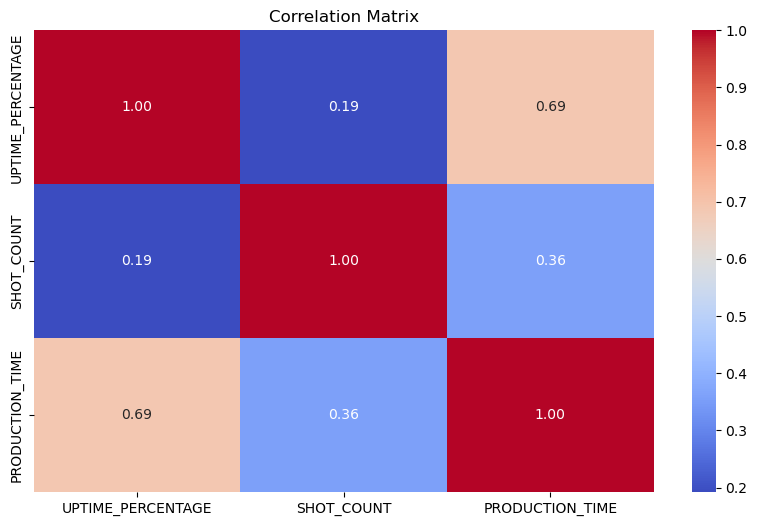

In [64]:
def analyze_correlation(df):
    """
    This function calculates and visualizes the correlation matrix for 'UPTIME_PERCENTAGE', 
    'SHOT_COUNT', and 'PRODUCTION_TIME'. The interpretation of the correlation values is as follows:

    1. Correlation between UPTIME_PERCENTAGE and SHOT_COUNT:
       Value: 0.189049 (Weak Positive Correlation)
       This means there is a slight positive relationship between UPTIME_PERCENTAGE and SHOT_COUNT. 
       As uptime percentage increases, there is a tendency for the shot count to increase slightly, but 
       the relationship is not very strong. A correlation of 0.19 suggests that other factors might be 
       influencing shot count more significantly than uptime percentage.

    2. Correlation between UPTIME_PERCENTAGE and PRODUCTION_TIME:
       Value: 0.691661 (Moderate Positive Correlation)
       This shows a moderate positive correlation, meaning that as the uptime percentage increases, 
       production time tends to increase as well. Uptime percentage is likely related to the amount of 
       time the tool is running, so higher uptime would lead to more production time. The correlation 
       of 0.69 suggests that there is a reasonably strong relationship between these two variables.

    3. Correlation between SHOT_COUNT and PRODUCTION_TIME:
       Value: 0.353257 (Weak Positive Correlation)
       There is a weak positive correlation between SHOT_COUNT and PRODUCTION_TIME. As shot count increases, 
       production time also tends to increase, but the relationship is not strong. This indicates that while 
       more shots may lead to more production time, the increase in production time is not necessarily proportional 
       to the shot count.

    What Does This Tell Us?
    - **Uptime and Production Time**: The stronger correlation between UPTIME_PERCENTAGE and PRODUCTION_TIME (0.69) suggests that uptime percentage is a significant factor influencing production time. 
      When uptime increases, production time tends to increase as well, likely due to the fact that higher uptime implies more continuous operation.
      
    - **Shot Count's Influence**: While there is a weak positive correlation between SHOT_COUNT and UPTIME_PERCENTAGE (0.19), it’s not very strong, indicating that uptime alone doesn’t have a major impact on the shot count. 
      Similarly, the weak positive correlation between SHOT_COUNT and PRODUCTION_TIME (0.35) suggests that while shot count influences production time, there might be other factors (such as machine efficiency or downtime) playing a significant role in production time.
    """
    
    # Option 1: Drop rows with NaN values (already done, but verify if CYCLE_TIME_LIMIT1 still has NaN)
df_cleaned = df.dropna(subset=['UPTIME_PERCENTAGE', 'SHOT_COUNT', 'PRODUCTION_TIME'])

# Option 2: Fill NaN values in 'CYCLE_TIME_LIMIT1' with the mean (if desired)
df['CYCLE_TIME_LIMIT1'].fillna(df['CYCLE_TIME_LIMIT1'].mean(), inplace=True)

# Now proceed with the correlation matrix calculation
df_cleaned = df[['UPTIME_PERCENTAGE','SHOT_COUNT', 'PRODUCTION_TIME']].dropna()

# Calculate the correlation matrix
correlation_matrix = df_cleaned.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [65]:
#predictive modeling 

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

"""
This code implements a predictive model to estimate the UPTIME_PERCENTAGE based on the features
'SHOT_COUNT', 'CONTRACTED_CYCLE_TIME', and 'PRODUCTION_TIME' using a RandomForestRegressor.

The model's performance is evaluated using the **Root Mean Squared Error (RMSE)**, which is a common
metric to assess the quality of regression models. RMSE represents the average magnitude of the 
errors between the predicted values and the actual values. It is calculated by taking the square root 
of the mean of squared differences between predicted and true values. A lower RMSE indicates better 
model performance, as it suggests that the predicted values are closer to the actual values.

In this case, the calculated RMSE value is **4.05**, meaning that, on average, the model's predictions 
for the UPTIME_PERCENTAGE deviate by approximately 4.05 percentage points from the actual values. 

While this RMSE suggests that the model has reasonable predictive accuracy, further improvements 
could be made by tuning the model or experimenting with additional features to reduce the error and 
increase the model's performance.
"""




# lets prepare the dataset for regression model( we will try to predict the uptime percentage)

features = ['SHOT_COUNT', 'CONTRACTED_CYCLE_TIME', 'PRODUCTION_TIME']
target = 'UPTIME_PERCENTAGE'

df = df.dropna(subset=features)


x = df[features]   
y= df[target]

#train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)  # 70% training and 30% testing

#train a random forest model
model = RandomForestRegressor()
model.fit(x_train, y_train)

#predict and evaluate the model
predictions = model.predict(x_test) 
print('RMSE:' , mean_squared_error(y_test, predictions, squared=False))

RMSE: 4.052697919571587


Equipment and Plant Level Analysis

/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_20074/2237957977.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




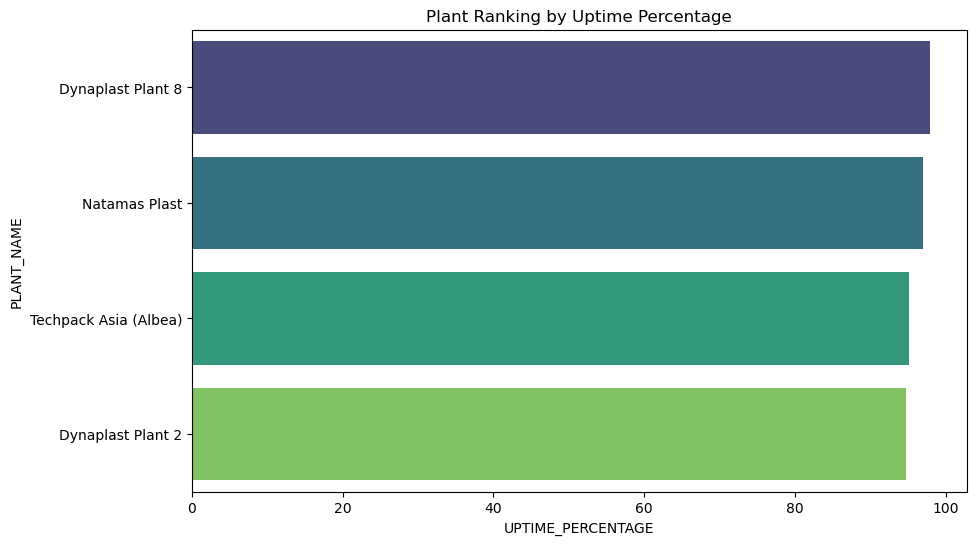

In [66]:
plant_ranking = df.groupby('PLANT_NAME')['UPTIME_PERCENTAGE'].mean().sort_values(ascending=False).reset_index()

#visualize plant ranking
plt.figure(figsize=(10, 6))
sns.barplot(data=plant_ranking, x='UPTIME_PERCENTAGE', y='PLANT_NAME', palette = 'viridis')
plt.title('Plant Ranking by Uptime Percentage')
plt.show()

Cluster Analysis

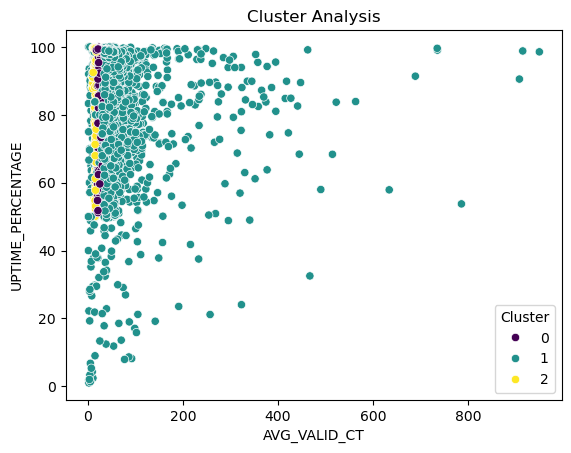

In [67]:
#lets do a cluster analysis

from sklearn.cluster import KMeans

"""
This code performs a Cluster Analysis using the KMeans algorithm to group data points into clusters based on selected features.

1. Feature Selection: The features used for clustering are:
   - `AVG_VALID_CT` (Average Valid Cycle Time)
   - `SHOT_COUNT` (Number of Shots)
   - `UPTIME_PERCENTAGE` (Percentage of Uptime)

   These features are selected to identify patterns or groups of similar data points based on their characteristics.

2. KMeans Clustering: The KMeans algorithm is applied to the selected features. The number of clusters is set to 3 (`n_clusters=3`), meaning that the algorithm will group the data into 3 clusters. The `random_state=42` ensures reproducibility by using a fixed random seed for the initialization of centroids.

3. Cluster Assignment: The model predicts cluster labels for each data point, and these labels are stored in a new column called `Cluster`. Each data point is assigned to one of the 3 clusters based on its similarity to other points in the dataset.

4. Visualization: A scatter plot is generated to visualize the clustering result. The plot shows the relationship between `AVG_VALID_CT` and `UPTIME_PERCENTAGE`, with points color-coded according to their cluster label. The `hue='Cluster'` parameter ensures that the points are colored based on their assigned cluster, and the `viridis` color palette is used for distinguishing the clusters.

   - The plot allows for a visual assessment of how well the data points are grouped into clusters and the separation between the clusters.

The result of this analysis can help in understanding patterns or groupings within the data, providing insights into different types of behavior based on the selected features.
"""


#lets select some feautures for clustering

cluster_features = df[['AVG_VALID_CT','SHOT_COUNT' , 'UPTIME_PERCENTAGE']]
kmeans = KMeans(n_clusters=3, random_state = 42)
df['Cluster'] = kmeans.fit_predict(cluster_features)

#lets vidualize it again
sns.scatterplot(data=df, x='AVG_VALID_CT', y='UPTIME_PERCENTAGE', hue='Cluster', palette='viridis')
plt.title('Cluster Analysis')
plt.show()

Sales Specific analysis


              PLANT_NAME  IDLE_TIME  Lost_Revenue
0      Dynaplast Plant 2     446220        446220
1      Dynaplast Plant 8      76327         76327
2          Natamas Plast     628308        628308
3  Techpack Asia (Albea)    3259563       3259563


/var/folders/7t/gk_qv83x7jzdycfbpkl_k40r0000gn/T/ipykernel_20074/3830632361.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




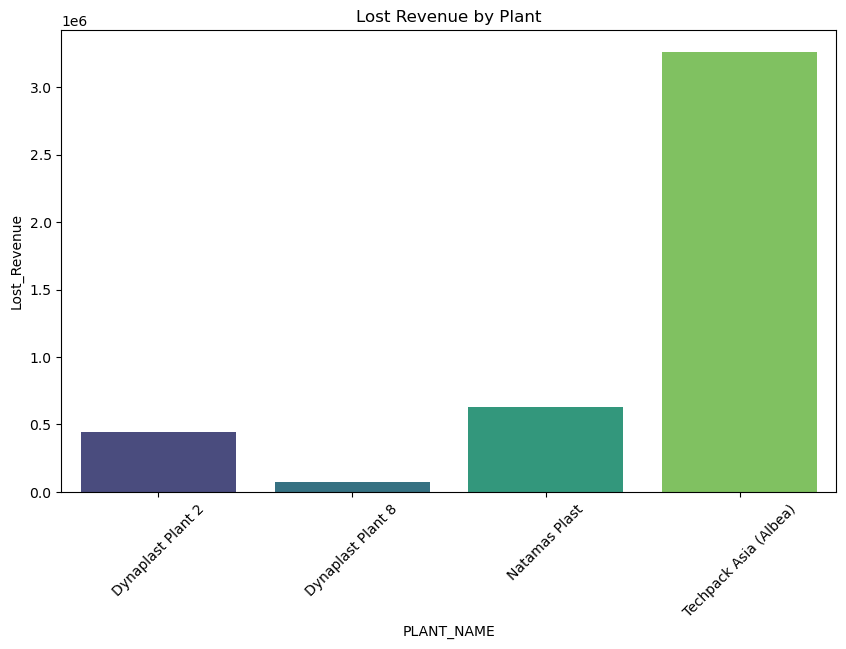

In [68]:
# Estimate lost revenue using a placeholder revenue per hour rate (e.g., $1 per hour)
REVENUE_PER_HOUR = 1  # Placeholder value, you would replace this with a real rate

# Calculate lost revenue
df['Lost_Revenue'] = df['IDLE_TIME'] * REVENUE_PER_HOUR

# Aggregate lost revenue by plant
revenue_impact = df.groupby('PLANT_NAME').agg({
    'IDLE_TIME': 'sum', 
    'Lost_Revenue': 'sum'
}).reset_index()

print(revenue_impact)

# Visualize the lost revenue by plant
plt.figure(figsize=(10, 6))
sns.barplot(data=revenue_impact, x='PLANT_NAME', y='Lost_Revenue', palette='viridis')
plt.title('Lost Revenue by Plant')
plt.xticks(rotation=45)
plt.show()


performance reports

In [69]:
#lets make a performance based report for the management( using equipment code and plant name)
performance_report = df.groupby('EQUIPMENT_CODE').agg({
    'UPTIME_PERCENTAGE': 'mean',
    'SHOT_COUNT': 'sum',
    'IDLE_TIME': 'sum'
}).reset_index()

print(performance_report)    

           EQUIPMENT_CODE  UPTIME_PERCENTAGE  SHOT_COUNT  IDLE_TIME
0   221000098-01-N01-1001          97.473512       49160       8525
1   221000098-02-N01-1001          98.189140      128660      21283
2   221000098-03-N01-1001          97.732917      167278      46519
3            500001070/78          94.010225       69716      93904
4          500001071/79 A          96.214868       12996       1557
..                    ...                ...         ...        ...
70                MI00274          95.904364       20612      17572
71                MI00275          61.405455         214       2206
72                MI00276          94.818719       30582      35186
73            YY-1907-130          96.942973        5863       3449
74            YY-2009-318          99.066927       80316       9325

[75 rows x 4 columns]


Trend Insights

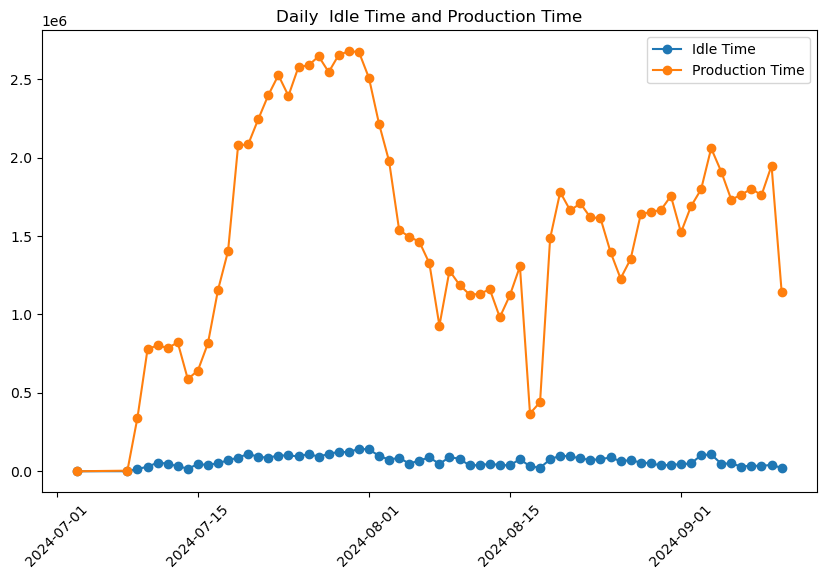

In [70]:
# Convert 'START_TIME' to datetime format (if it's not already)
df['START_TIME'] = pd.to_datetime(df['START_TIME'], errors='coerce')

# Filter the dataframe to start from 2024-01-01
df_filtered = df[df['START_TIME'] >= '2024-07-01']

# Group by date and aggregate 'CONTRACTED_CYCLE_TIME', 'IDLE_TIME' and 'PRODUCTION_TIME'
daily_production = df_filtered.groupby(df_filtered['START_TIME'].dt.date).agg({
    'IDLE_TIME': 'sum',
    'PRODUCTION_TIME': 'sum'
}).reset_index()

# Create the plot
plt.figure(figsize=(10, 6))



# Plot IDLE_TIME and PRODUCTION_TIME
plt.plot(daily_production['START_TIME'], daily_production['IDLE_TIME'], marker='o', label='Idle Time')
plt.plot(daily_production['START_TIME'], daily_production['PRODUCTION_TIME'], marker='o', label='Production Time')

# Title and labels
plt.title('Daily  Idle Time and Production Time')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Display the plot
plt.show()


In [71]:
import plotly.graph_objects as go

# Convert time from seconds to hours
daily_production['IDLE_TIME_hours'] = daily_production['IDLE_TIME'] / 3600
daily_production['PRODUCTION_TIME_hours'] = daily_production['PRODUCTION_TIME'] / 3600

# Create an interactive line plot for IDLE_TIME (in hours) and PRODUCTION_TIME (in hours)

fig = go.Figure()

# Add Idle Time (in hours) to the plot
fig.add_trace(go.Scatter(
    x=daily_production['START_TIME'],
    y=daily_production['IDLE_TIME_hours'],  # Use the hours column
    mode='lines+markers',
    name='Idle Time (hours)',
    line=dict(color='red')
))

# Add Production Time (in hours) to the plot
fig.add_trace(go.Scatter(
    x=daily_production['START_TIME'],
    y=daily_production['PRODUCTION_TIME_hours'],  # Use the hours column
    mode='lines+markers',
    name='Production Time (hours)',
    line=dict(color='green')
))

# Customize the layout of the plot
fig.update_layout(
    title='Daily Idle Time and Production Time (in Hours)',
    xaxis_title='Date',
    yaxis_title='Time (hours)',
    xaxis=dict(tickformat="%Y-%m-%d"),  # Format x-axis as date
    legend=dict(title='Legend'),
    template='plotly_dark'  # Dark theme for the plot
)

# Show the plot
fig.show()


In [72]:
import plotly.subplots as sp

# Convert time from seconds to hours
daily_production['IDLE_TIME_hours'] = daily_production['IDLE_TIME'] / 3600
daily_production['PRODUCTION_TIME_hours'] = daily_production['PRODUCTION_TIME'] / 3600

# Create subplots: 1 row, 2 columns
fig = sp.make_subplots(
    rows=1, cols=2,
    subplot_titles=('Idle Time', 'Production Time'),
    shared_yaxes=True
)

# Add Idle Time plot to the first subplot (left)
fig.add_trace(go.Scatter(
    x=daily_production['START_TIME'],
    y=daily_production['IDLE_TIME_hours'],
    mode='lines+markers',
    name='Idle Time',
    line=dict(color='red')
), row=1, col=1)

# Add Production Time plot to the second subplot (right)
fig.add_trace(go.Scatter(
    x=daily_production['START_TIME'],
    y=daily_production['PRODUCTION_TIME_hours'],
    mode='lines+markers',
    name='Production Time',
    line=dict(color='green')
), row=1, col=2)

# Update layout and axis titles
fig.update_layout(
    title='Idle Time and Production Time Comparison',
    xaxis_title='Date',
    yaxis_title='Time (hours)',
    xaxis=dict(tickformat="%Y-%m-%d"),
    showlegend=False,
    template='plotly_dark'
)

# Show the plot
fig.show()


In [ ]:
#throwing some NLP analysis just to make it more interesting

from transformers import pipeline

#load equipment_code data 

log_data = df['COMPANY_NAME'].dropna().tolist() # it is important to drop the null values first

#summarize logs using huggingface's pre -trained model 

summarizer = pipeline('summarization', model= 't5-small')
summaries = [summarizer(log, max_length=8, min_length=2, do_sample = False)[0]['summary_text'] for log in log_data]   


#lets add summaries to dataframe
df['Log_summary'] = summaries
df[['COMPANY_NAME', 'Log_summary']].head()    

In [73]:
import openai

openai.api_key = 'sk-1234567890abcdef1234567890abcdef'

def ask_gpt(prompt):
    response = openai.ChatCompletion.create(
        model="gpt-3.5-turbo",  # You can use models like gpt-3.5-turbo or gpt-4
        messages=[{"role": "user", "content": prompt}],
        max_tokens=100,
        temperature=0.7
    )
    return response['choices'][0]['message']['content'].strip()

# Example question
question = 'What is the uptime percentage of equipment code 1234?'
print(ask_gpt(question))


APIRemovedInV1: 

You tried to access openai.ChatCompletion, but this is no longer supported in openai>=1.0.0 - see the README at https://github.com/openai/openai-python for the API.

You can run `openai migrate` to automatically upgrade your codebase to use the 1.0.0 interface. 

Alternatively, you can pin your installation to the old version, e.g. `pip install openai==0.28`

A detailed migration guide is available here: https://github.com/openai/openai-python/discussions/742


In [74]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

"""
Feature Importance Explanation:

The output array represents the importance of each feature used by the Gradient Boosting Regressor model for predicting the `UPTIME_PERCENTAGE`. The values indicate how much each feature contributes to the model's ability to explain the variance in the target variable.

The features and their corresponding importance values are:

1. PRODUCTION_TIME (0.2426): This feature has the highest importance. It indicates that the amount of time spent in production has a significant impact on the model's ability to predict the uptime percentage.
2. TOTAL_SESSION_TIME (0.0014): This feature contributes a small amount to the prediction. Although it’s somewhat relevant, it has a minimal influence on uptime percentage.
3. SHOT_COUNT(0.0012): The number of shots made also has a small impact on the prediction, though not as significant as other features like `PRODUCTION_TIME`.
4. IDLE_TIME (0.7546): This is the most important feature by far, indicating a strong inverse relationship with uptime percentage. More idle time leads to a lower uptime percentage.
5. CONTRACTED_CYCLE_TIME(negligible): This feature contributes an extremely small amount to the model's prediction. It may not have much predictive power in this case.
6. L1_ABOVE_ADJUSTED (negligible): This feature has almost no impact on predicting uptime percentage.
7. L2_ABOVE_ADJUSTED (0.0): This feature has zero importance, suggesting that it doesn’t help in predicting uptime.
8. L1_BELOW_ADJUSTED (0.00002): This feature has a very small but non-zero impact on the model's predictions.
9. L2_BELOW_ADJUSTED (negligible): This feature has an almost negligible importance in predicting uptime percentage.
10. DAY (0.00005): The day of the week or day of the year has very minimal impact on uptime prediction.
11. MONTH(0.00002): The month of the year also shows a negligible effect on uptime prediction.
12. YEAR (0.0): The year has zero importance, meaning it does not provide any useful information for predicting uptime.

In summary:
- `IDLE_TIME` and `PRODUCTION_TIME` are the most influential features in predicting uptime, with `IDLE_TIME` having the largest impact. 
- Other features, such as `SHOT_COUNT` and `TOTAL_SESSION_TIME`, have smaller but non-zero contributions to the model. 
- Temporal features like `DAY`, `MONTH`, and `YEAR`have very little or no impact on uptime prediction.
"""


# Defining the features and target
features = ['PRODUCTION_TIME', 'TOTAL_SESSION_TIME', 'SHOT_COUNT', 'IDLE_TIME', 
            'CONTRACTED_CYCLE_TIME', 'L1_ABOVE_ADJUSTED', 'L2_ABOVE_ADJUSTED', 
            'L1_BELOW_ADJUSTED', 'L2_BELOW_ADJUSTED', 'DAY', 'MONTH', 'YEAR']
target = 'UPTIME_PERCENTAGE'

# X (features) and y (target) are extracted from the dataframe
x = df[features]    
y = df[target]

# Split the data into training and testing sets (70% training, 30% testing)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Initialize the Gradient Boosting Regressor model
model = GradientBoostingRegressor()

# Train the model using the training data
model.fit(x_train, y_train)

# Make predictions on the test data
predictions = model.predict(x_test)

# Extract the feature importances from the trained model
feature_importance = model.feature_importances_

# Output the feature importances
print('Feature Importance:', feature_importance)


Feature Importance: [2.42604113e-01 1.42707234e-03 1.26949403e-03 7.54602449e-01
 1.98493874e-05 0.00000000e+00 2.04959796e-06 7.93530939e-06
 6.31751981e-06 4.45075525e-05 1.62126143e-05 0.00000000e+00]


In [75]:
#optimizing the threshold 

from scipy.optimize import minimize 
"""
Threshold Optimization Explanation:

This code is attempting to optimize the thresholds for `CYCLE_TIME_LIMIT1` and `CYCLE_TIME_LIMIT2` in order to minimize the `IDLE_TIME`. The objective is to find the values of these cycle time limits that result in the least amount of idle time, which directly improves uptime percentage.

The optimization process is carried out using the `scipy.optimize.minimize` function. Here's a breakdown of the process:

1. Objective Function (`objective`):
    - The function `objective` takes in `params`, which consists of two parameters: `cycle1` and `cycle2`, representing the cycle time limits (`CYCLE_TIME_LIMIT1` and `CYCLE_TIME_LIMIT2`).
    - The function filters the data in the dataframe (`df`) where both `CYCLE_TIME_LIMIT1` is greater than `cycle1` and `CYCLE_TIME_LIMIT2` is greater than `cycle2`, and then sums up the `IDLE_TIME` for these filtered rows.
    - The goal of the optimization is to minimize this sum of `IDLE_TIME` by adjusting the values of `cycle1` and `cycle2`.

2. Optimization:
    - The `minimize` function is used to find the optimal values for `cycle1` and `cycle2`. The initial guess is provided by `x0 = [100, 200]`, meaning the optimization starts with `CYCLE_TIME_LIMIT1 = 100` and `CYCLE_TIME_LIMIT2 = 200`.
    - The bounds for the optimization are specified by `bounds = [(50, 150), (150, 3000)]`. This restricts `CYCLE_TIME_LIMIT1` to be between 50 and 150, and `CYCLE_TIME_LIMIT2` to be between 150 and 3000.

3. Result:
    - The `result.x` contains the optimal values for `cycle1` and `cycle2` that minimize the `IDLE_TIME`. In this case, the optimization results in the following values for the thresholds:
      - `CYCLE_TIME_LIMIT1 = 100`
      - `CYCLE_TIME_LIMIT2 = 200`

4. Conclusion:
    - The optimal thresholds found are `100` for `CYCLE_TIME_LIMIT1` and `200` for `CYCLE_TIME_LIMIT2`. These values lead to the minimum `IDLE_TIME`, indicating the best cycle time limits for optimizing uptime.

In summary, the optimization process adjusts the cycle time limits to minimize idle time, with the resulting optimal thresholds being `100` and `200`.
"""


def objective(params):
    cycle1, cycle2= params
    idle_time = df[(df['CYCLE_TIME_LIMIT1'] > cycle1) & (df['CYCLE_TIME_LIMIT2'] > cycle2)]['IDLE_TIME'].sum()
    return idle_time

#optimization
result = minimize(objective, x0 =[100,200], bounds =[(50,150),(150,3000)])
optimal_thresholds = result.x   
print('optimal thresholds:', optimal_thresholds)

optimal thresholds: [100. 200.]


Automation

In [76]:
#reporting and automation
import dash
from dash import html,dcc
import plotly.express as px 

#creating an app
app = dash.Dash(__name__)

#example plotly figure 
fig = px.bar(revenue_impact, x='PLANT_NAME', y='Lost_Revenue', color='PLANT_NAME', title='Lost Revenue by Plant')

#app layout 
app.layout = html.Div([
    html.H1('Paragon Manufacturing Dashboard'),
    dcc.Graph(figure=fig)
])

#run the app
if __name__ == '__main__':
    app.run_server(debug=True)

gaierror: [Errno 8] nodename nor servname provided, or not known

In [ ]:
#automated email reports

import smtplib  
from email.mime.text import MIMEText    
from email.mime.multipart import MIMEMultipart

#email settings
sender_email = 'ugulbardak@gmail.com' # my own email address
receiver_email = 'ugulbardak@gmail.com' # example email address
subject = 'Paragon Manufacturing Report'

#content
message = MIMEMultipart() 
message['From'] = sender_email
message['To'] = receiver_email
message['Subject'] = subject
message.attach(MIMEText('Please find the attached report', 'plain'))

#sending email
with smtplib.SMTP('smtp.gmail.com', 587) as server:
    server.starttls()
    server.login(sender_email, '*****') # password is hidden for security reasons, should add the real password later
    server.sendmail(sender_email, receiver_email, message.as_string())